In [1]:
# Data Manipulations
import pandas as pd
import numpy as np

# Handling Images
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# Pytorch Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Dataset
import torchsummary

# Data augmentation
import torchvision
from torchvision import datasets, transforms, utils
from torchvision.transforms import v2

import os
from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , accuracy_score, classification_report

In [2]:
!pip install opendatasets

In [3]:
import opendatasets as od
od.download('https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: authenticradio
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


In [4]:
train_df = pd.DataFrame({
    "path":[],
    "label":[],
    "class_id":[]
})

train_path = '/content/brain-tumor-mri-dataset/Training'
folder_list = os.listdir(train_path)
print(folder_list)

['meningioma', 'notumor', 'pituitary', 'glioma']


In [5]:
label_dict = {
    'glioma':0,
    'meningioma':1,
    'notumor':2,
    'pituitary':3
}

In [6]:
for i, folder in enumerate(folder_list):
  img_path = os.path.join(train_path, folder)
  jpg_list = glob(img_path+'/*.jpg')
  for jpg in jpg_list:
    new_data =pd.DataFrame({"path":jpg,"label":folder, "class_id":label_dict[folder]}, index=[1])
    train_df = pd.concat([train_df, new_data], ignore_index=True)

In [7]:
train_df[["path"]] = train_df[["path"]].astype(str)
train_df[["label"]] = train_df[["label"]].astype(str)
train_df[["class_id"]] = train_df[["class_id"]].astype(int)

In [8]:
train_df.sample(5)

,path,label,class_id
5387,/content/brain-tumor-mri-dataset/Training/glio...,glioma,0
4905,/content/brain-tumor-mri-dataset/Training/glio...,glioma,0
1078,/content/brain-tumor-mri-dataset/Training/meni...,meningioma,1
4064,/content/brain-tumor-mri-dataset/Training/pitu...,pituitary,3
1745,/content/brain-tumor-mri-dataset/Training/notu...,notumor,2


In [9]:
val_df = pd.DataFrame({
    "path":[],
    "label":[],
    "class_id":[]
})
val_path = '/content/brain-tumor-mri-dataset/Testing'
folder_list = os.listdir(val_path)
print(folder_list)

['meningioma', 'notumor', 'pituitary', 'glioma']


In [10]:
for i, folder in enumerate(folder_list):
    img_path = os.path.join(val_path, folder)
    jpg_list = glob(img_path+'/*.jpg')
    for jpg in jpg_list:
        new_data =pd.DataFrame({"path":jpg,"label":folder, "class_id":label_dict[folder]}, index=[1])
        val_df = pd.concat([val_df, new_data], ignore_index=True)

val_df[["path"]] = val_df[["path"]].astype(str)
val_df[["label"]] = val_df[["label"]].astype(str)
val_df[["class_id"]] = val_df[["class_id"]].astype(int)

In [11]:
val_df.sample(5)

,path,label,class_id
820,/content/brain-tumor-mri-dataset/Testing/pitui...,pituitary,3
1110,/content/brain-tumor-mri-dataset/Testing/gliom...,glioma,0
1198,/content/brain-tumor-mri-dataset/Testing/gliom...,glioma,0
567,/content/brain-tumor-mri-dataset/Testing/notum...,notumor,2
818,/content/brain-tumor-mri-dataset/Testing/pitui...,pituitary,3


In [12]:
train_df['class_id'].value_counts()

,count
class_id,
2,1595
3,1457
1,1339
0,1321


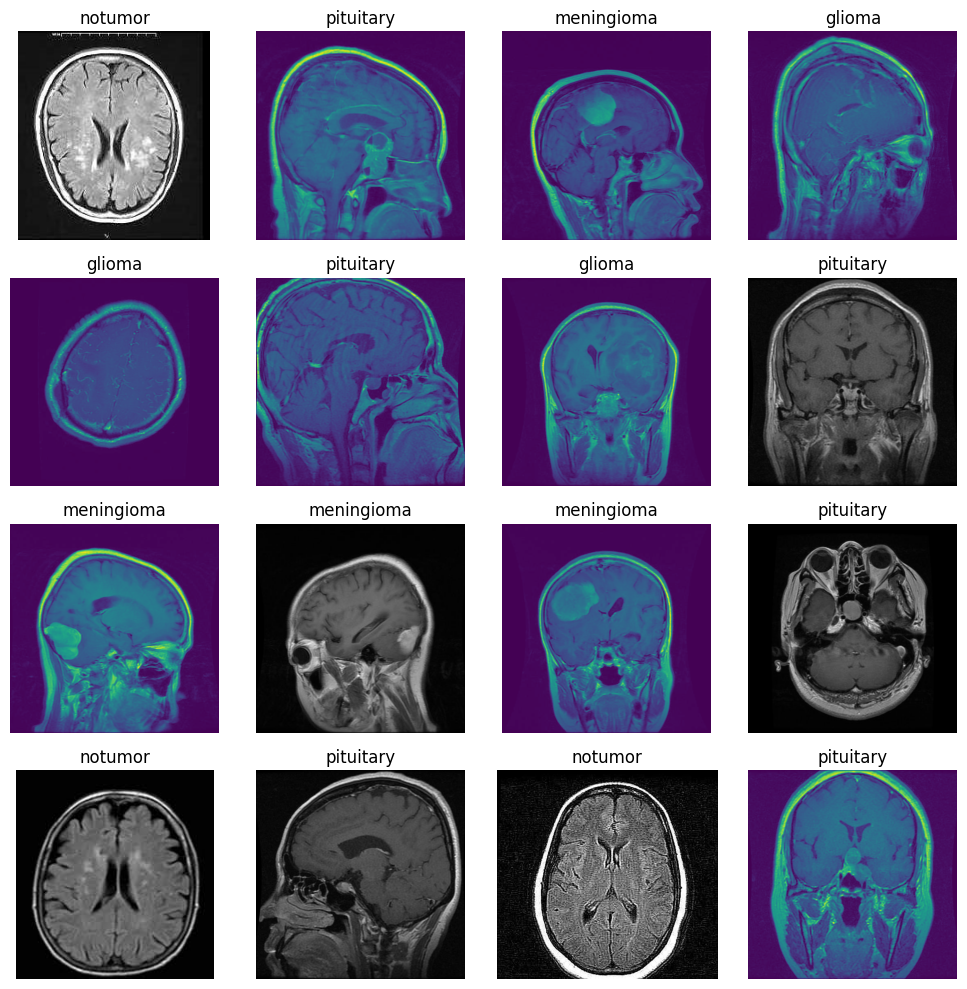

In [13]:
# Randomly select 16 images
sample_df = train_df.sample(n=16, random_state=42)  # Set random_state for reproducibility
image_paths = sample_df['path'].values
labels = sample_df['label'].values

# Create a 4x4 grid
plt.figure(figsize=(10, 10))

for i, (img_path, label) in enumerate(zip(image_paths, labels)):
    plt.subplot(4, 4, i + 1)
    img = Image.open(img_path)  # Open image
    plt.imshow(img)
    plt.axis("off")
    plt.title(label)

plt.tight_layout()
plt.show()

In [14]:
# Training data transformations
train_transforms = v2.Compose([
    v2.Resize(256),  # Resize the image to 256 pixels (preserving aspect ratio)
    v2.RandomResizedCrop(size=(224, 224), antialias=True),  # Randomly crop a 224x224 region
    v2.RandomHorizontalFlip(p=0.5),  # Flip the image horizontally with a 50% chance
    v2.RandomVerticalFlip(p=0.5),  # Flip the image vertically with a 50% chance
    v2.RandomAffine(degrees=(-10, 10),  # Rotate between -10° to 10°
                    translate=(0.1, 0.1),  # Shift up to 10% in x & y directions
                    scale=(0.9, 1.1)),  # Scale between 90% to 110%
    v2.RandomErasing(p=0.5, scale=(0.1, 0.15)),  # Erase a random patch of the image
    v2.PILToTensor(),  # Convert the image to a tensor (C, H, W)
    v2.ToDtype(torch.float32),  # Convert to float32 tensor
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize
])

# Testing data transformations
test_transforms = v2.Compose([
    v2.Resize((224, 224)),  # Resize to 224x224 (no cropping)
    v2.PILToTensor(),  # Convert to tensor
    v2.ToDtype(torch.float32),  # Convert to float32 tensor
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize
])


In [15]:
class MyDataset(Dataset):
    def __init__(self, dataframe, transforms_):
        self.df = dataframe
        self.transforms = transforms_  # Use transforms for augmentation & tensor conversion

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        image_path = self.df.iloc[index]['path']
        img = Image.open(image_path).convert('RGB')  # Open image & convert to RGB
        transformed_img = self.transforms(img)  # Apply transformations
        class_id = self.df.iloc[index]['class_id']
        return transformed_img, class_id

# Define datasets
train_dataset = MyDataset(train_df, train_transforms)
val_dataset = MyDataset(val_df, test_transforms)

# Define data loaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [16]:
print(f'train data:{len(train_df)}')
print(f'val data:{len(val_df)}')

train data:5712
val data:1311


In [17]:
class_size = 4
model = models.efficientnet_v2_s(weights='DEFAULT')

model.classifier[1] = torch.nn.Linear(1280, class_size)
model(torch.rand(16, 3, 256, 256)).shape

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth
100%|██████████| 82.7M/82.7M [00:00<00:00, 202MB/s]


torch.Size([16, 4])

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_workers = 2 if device=='cuda' else 4

In [21]:
def train(dataloader, model, loss_fn, optimizer, lr_scheduler):
    # Get dataset size and number of batches
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    # Set model to training mode
    model.train()
    epoch_loss = 0.0
    epoch_correct = 0

    # Loop through each batch of data
    for (data, target) in dataloader:
        # Convert target to correct type and move data to device
        target = target.type(torch.LongTensor)
        data, target = data.to(device), target.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass: get predictions
        outputs = model(data)

        # Calculate loss
        loss = loss_fn(outputs, target)

        # Backward pass: calculate gradients
        loss.backward()

        # Update model weights
        optimizer.step()

        # Track statistics
        epoch_loss += loss.item()
        _, pred = torch.max(outputs, dim=1)
        epoch_correct += torch.sum(pred == target).item()

    # Update learning rate
    lr_scheduler.step()

    # Return accuracy and average loss
    return epoch_correct/size, epoch_loss/num_batches


def test(dataloader, model, loss_fn):
    # Get dataset size and number of batches
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    epoch_loss = 0.0
    epoch_correct = 0

    # Disable gradient calculation for evaluation
    with torch.no_grad():
        # Set model to evaluation mode
        model.eval()

        # Loop through each batch of data
        for (data, target) in dataloader:
            # Convert target to correct type and move data to device
            target = target.type(torch.LongTensor)
            data, target = data.to(device), target.to(device)

            # Forward pass: get predictions
            outputs = model(data)

            # Calculate loss
            loss = loss_fn(outputs, target)

            # Track statistics
            epoch_loss += loss.item()
            _, pred = torch.max(outputs, dim=1)
            epoch_correct += torch.sum(pred == target).item()

    # Return accuracy and average loss
    return epoch_correct/size, epoch_loss/num_batches

In [22]:
# Move model to the right device (GPU or CPU)
model.to(device)

# Set number of training rounds
EPOCHS = 50

# Dictionary to track performance metrics
logs = {
    'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []
}

# Define loss function (measures prediction errors)
criterion = nn.CrossEntropyLoss()

# Configure optimizer settings
learning_rate = 0.0001
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# Learning rate scheduler (reduces learning rate at specific epochs)
lr_milestones = [7, 14, 21, 28, 35]
multi_step_lr_scheduler = lr_scheduler.MultiStepLR(optimizer, milestones=lr_milestones, gamma=0.1)

# Early stopping setup (stops training if model stops improving)
patience = 5
counter = 0
best_loss = np.inf

# Training loop
for epoch in tqdm(range(EPOCHS)):
    # Train for one epoch and get metrics
    train_acc, train_loss = train(train_loader, model, criterion, optimizer, multi_step_lr_scheduler)

    # Evaluate on validation data
    val_acc, val_loss = test(val_loader, model, criterion)

    # Print progress
    print(f'EPOCH: {epoch} \
    train_loss: {train_loss:.4f}, train_acc: {train_acc:.3f} \
    val_loss: {val_loss:.4f}, val_acc: {val_acc:.3f} \
    Learning Rate: {optimizer.param_groups[0]["lr"]}')

    # Store metrics
    logs['train_loss'].append(train_loss)
    logs['train_acc'].append(train_acc)
    logs['val_loss'].append(val_loss)
    logs['val_acc'].append(val_acc)

    # Save current model state
    torch.save(model.state_dict(), "last.pth")

    # Early stopping check
    if val_loss < best_loss:
        counter = 0
        best_loss = val_loss
        torch.save(model.state_dict(), "best.pth")  # Save best model
    else:
        counter += 1

    # Stop training if no improvement for 'patience' epochs
    if counter >= patience:
        print("Earlystop!")
        break

  0%|          | 0/50 [00:00<?, ?it/s]

EPOCH: 0     train_loss: 0.5391, train_acc: 0.799     val_loss: 0.1948, val_acc: 0.939     Learning Rate: 0.0001


  2%|▏         | 1/50 [01:46<1:26:44, 106.22s/it]

EPOCH: 1     train_loss: 0.2651, train_acc: 0.907     val_loss: 0.1040, val_acc: 0.969     Learning Rate: 0.0001


  4%|▍         | 2/50 [03:32<1:25:08, 106.43s/it]

...

EPOCH: 15     train_loss: 0.0922, train_acc: 0.968     val_loss: 0.0241, val_acc: 0.995     Learning Rate: 1.0000000000000002e-06


 32%|███▏      | 16/50 [28:29<1:00:53, 107.45s/it]

EPOCH: 16     train_loss: 0.0985, train_acc: 0.967     val_loss: 0.0239, val_acc: 0.995     Learning Rate: 1.0000000000000002e-06


 32%|███▏      | 16/50 [30:16<1:04:20, 113.54s/it]

Earlystop!


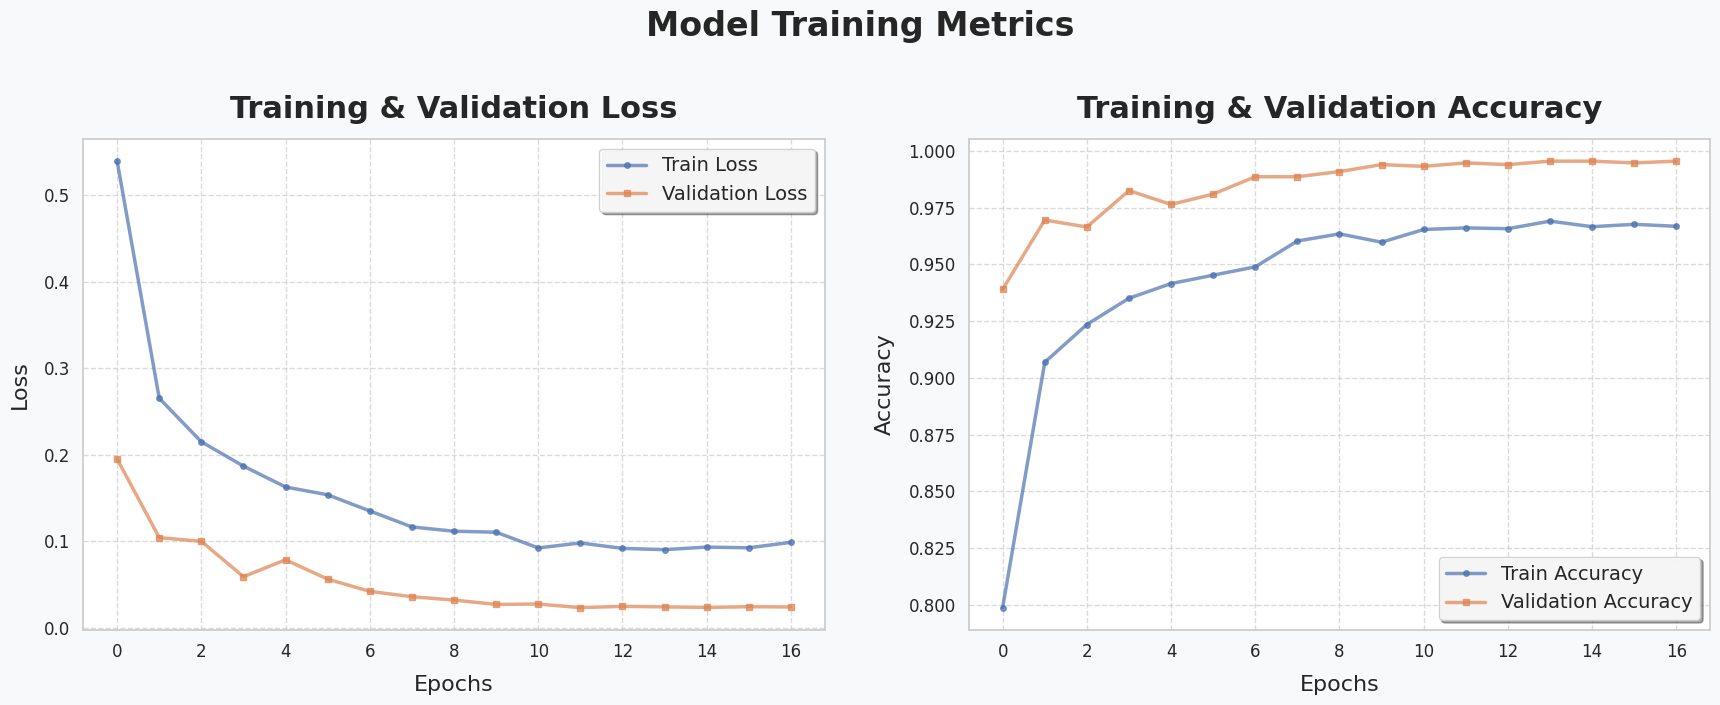

In [23]:
# Set the seaborn aesthetic parameters
sns.set(style="whitegrid")  # Use whitegrid style for better readability

# Use default system fonts instead of specifying Arial which may not be available
plt.rcParams['font.family'] = 'DejaVu Sans'  # This is usually available on most systems

# Create a figure with larger size and better resolution
plt.figure(figsize=(18, 7), dpi=100)

# First subplot - Loss
plt.subplot(1, 2, 1)
with sns.color_palette("viridis", 2):  # Using viridis color palette
    plt.plot(logs['train_loss'], linewidth=2.5, marker='o', markersize=4, alpha=0.7, label='Train Loss')
    plt.plot(logs['val_loss'], linewidth=2.5, marker='s', markersize=4, alpha=0.7, label='Validation Loss')

# Enhance the title and labels
plt.title('Training & Validation Loss', fontsize=22, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=16, labelpad=10)
plt.ylabel('Loss', fontsize=16, labelpad=10)
plt.legend(fontsize=14, frameon=True, facecolor='white', framealpha=0.9,
           shadow=True, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tick_params(axis='both', which='major', labelsize=12)

# Second subplot - Accuracy
plt.subplot(1, 2, 2)
with sns.color_palette("magma", 2):  # Using magma color palette for contrast
    plt.plot(logs['train_acc'], linewidth=2.5, marker='o', markersize=4, alpha=0.7, label='Train Accuracy')
    plt.plot(logs['val_acc'], linewidth=2.5, marker='s', markersize=4, alpha=0.7, label='Validation Accuracy')

# Enhance the title and labels
plt.title('Training & Validation Accuracy', fontsize=22, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=16, labelpad=10)
plt.ylabel('Accuracy', fontsize=16, labelpad=10)
plt.legend(fontsize=14, frameon=True, facecolor='white', framealpha=0.9,
           shadow=True, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tick_params(axis='both', which='major', labelsize=12)

# Add a subtle background color to the entire figure
fig = plt.gcf()
fig.patch.set_facecolor('#f8f9fa')

# Improve spacing between subplots
plt.tight_layout(pad=3.0)

# Optional: Add a suptitle for the entire figure
plt.suptitle('Model Training Metrics', fontsize=24, fontweight='bold', y=1.05)

# Show the plot
plt.show()

In [24]:
model.load_state_dict(torch.load('best.pth'))
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for (data_,target_) in tqdm(val_loader):
        target_ = target_.type(torch.LongTensor)
        data_, target_ = data_.to(device), target_.to(device)
        outputs = model(data_)
        _,pred = torch.max(outputs,dim=1)
        y_true.extend(target_.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())
y_pred = np.array(y_pred)
y_true = np.array(y_true)

100%|██████████| 41/41 [00:09<00:00,  4.18it/s]


In [25]:
label_dict

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

In [26]:
target_names = ["glioma", "meningioma", "notumor", "pituitary"]
clf_report = classification_report(y_true, y_pred, target_names = target_names)
print(clf_report)

              precision    recall  f1-score   support

      glioma       1.00      0.99      0.99       300
  meningioma       0.99      0.99      0.99       306
     notumor       1.00      1.00      1.00       405
   pituitary       0.99      1.00      1.00       300

    accuracy                           0.99      1311
   macro avg       0.99      0.99      0.99      1311
weighted avg       0.99      0.99      0.99      1311



In [27]:
Acc = accuracy_score(y_true,y_pred)
print("accuracy is: {0:.3f}%".format(Acc * 100))

accuracy is: 99.466%
